In [15]:
import pandas as pd

orders = pd.read_csv("data/orders.csv")
products = pd.read_csv("data/products.csv")
aisles = pd.read_csv("data/aisles.csv")
departments = pd.read_csv("data/departments.csv")
op_prior = pd.read_csv("data/order_products__prior.csv")
op_train = pd.read_csv("data/order_products__train.csv")

In [16]:
def summarize_table(name, df):
    return pd.Series(
        {
            "rows": len(df),
            "columns": df.shape[1],
            "null_cells": int(df.isna().sum().sum()),
        },
        name=name,
    )

inventory = pd.concat(
    [
        summarize_table("orders", orders),
        summarize_table("products", products),
        summarize_table("aisles", aisles),
        summarize_table("departments", departments),
        summarize_table("order_products__prior", op_prior),
        summarize_table("order_products__train", op_train),
    ],
    axis=1,
).T.sort_values("rows", ascending=False)

inventory

,rows,columns,null_cells
order_products__prior,32434489,4,0
orders,3421083,7,206209
order_products__train,1384617,4,0
products,49688,4,0
aisles,134,2,0
departments,21,2,0


In [17]:
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

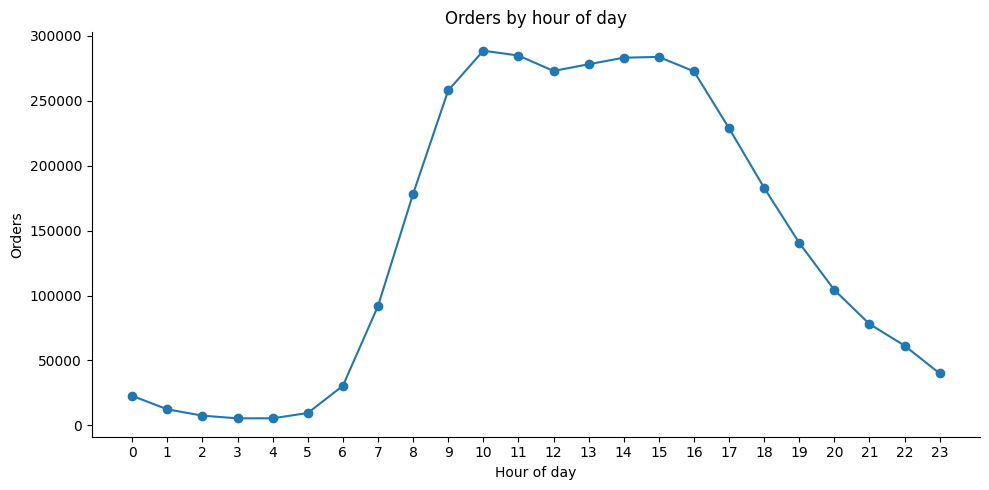

In [18]:
hourly_orders = orders.groupby("order_hour_of_day").size()
peak_hour = int(hourly_orders.idxmax())

ax = hourly_orders.plot(marker="o", title="Orders by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Orders")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

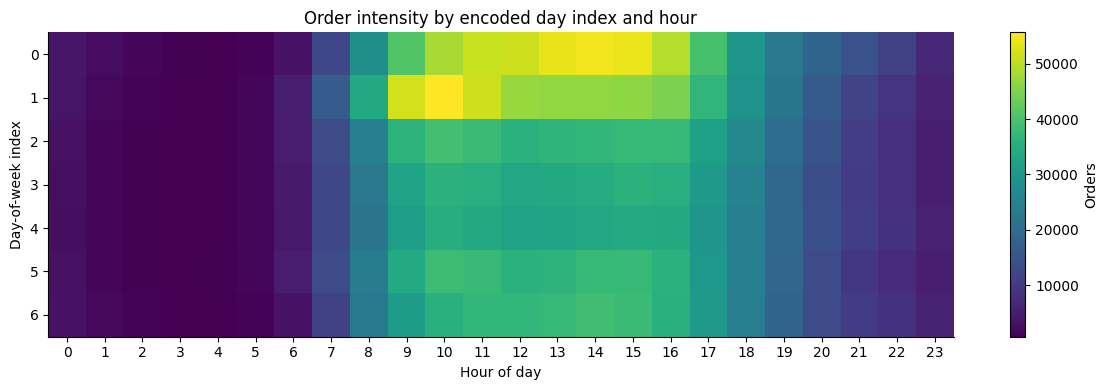

In [19]:
dow_hour = orders.groupby(["order_dow", "order_hour_of_day"]).size().unstack(fill_value=0)
plt.figure(figsize=(12, 4))
plt.imshow(dow_hour.values, aspect="auto")
plt.colorbar(label="Orders")
plt.xticks(range(24), range(24))
plt.yticks(range(len(dow_hour.index)), dow_hour.index)
plt.xlabel("Hour of day")
plt.ylabel("Day-of-week index")
plt.title("Order intensity by encoded day index and hour")
plt.tight_layout()
plt.show()

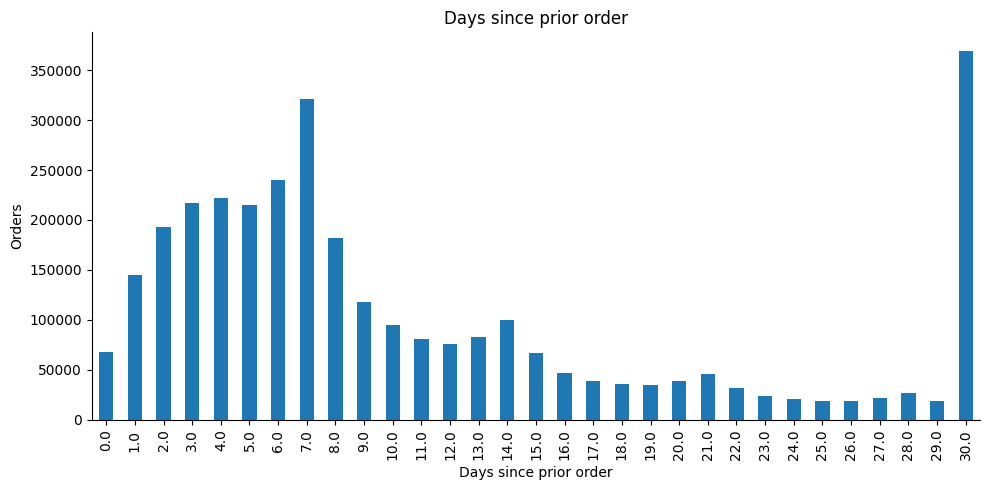

In [20]:
gap_counts = orders["days_since_prior_order"].dropna().value_counts().sort_index()
ax = gap_counts.plot.bar(title="Days since prior order")
ax.set_xlabel("Days since prior order")
ax.set_ylabel("Orders")
plt.tight_layout()
plt.show()


In [21]:
day_peak = dow_hour.stack().idxmax()
print(
    f"- Peak ordering hour: {peak_hour}:00\n"
    f"- Median days since prior order: {orders['days_since_prior_order'].median():.1f}\n"
)

- Peak ordering hour: 10:00
- Median days since prior order: 7.0



In [22]:
dim_products = (
    products
    .merge(aisles, on="aisle_id", how="left", validate="many_to_one")
    .merge(departments, on="department_id", how="left", validate="many_to_one")
)

order_products_all = pd.concat([op_prior, op_train], ignore_index=True)

fact_order_items = order_products_all.merge(
    orders[
        [
            "order_id",
            "user_id",
            "eval_set",
            "order_number",
            "order_dow",
            "order_hour_of_day",
            "days_since_prior_order",
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
)

product_demand = (
    fact_order_items.groupby("product_id")
    .agg(
        items=("product_id", "size"),
        unique_users=("user_id", "nunique"),
        reorder_rate=("reordered", "mean"),
        avg_cart_position=("add_to_cart_order", "mean"),
    )
    .reset_index()
    .merge(dim_products, on="product_id", how="left", validate="one_to_one")
)
product_demand["reordered_items"] = product_demand["items"] * product_demand["reorder_rate"]

department_metrics = (
    product_demand.groupby(["department_id", "department"], as_index=False)
    .agg(
        items=("items", "sum"),
        products=("product_id", "nunique"),
        reordered_items=("reordered_items", "sum"),
    )
)
department_metrics["reorder_rate"] = department_metrics["reordered_items"] / department_metrics["items"]

aisle_metrics = (
    product_demand.groupby(["aisle_id", "aisle"], as_index=False)
    .agg(
        items=("items", "sum"),
        products=("product_id", "nunique"),
        reordered_items=("reordered_items", "sum"),
    )
)
aisle_metrics["reorder_rate"] = aisle_metrics["reordered_items"] / aisle_metrics["items"]


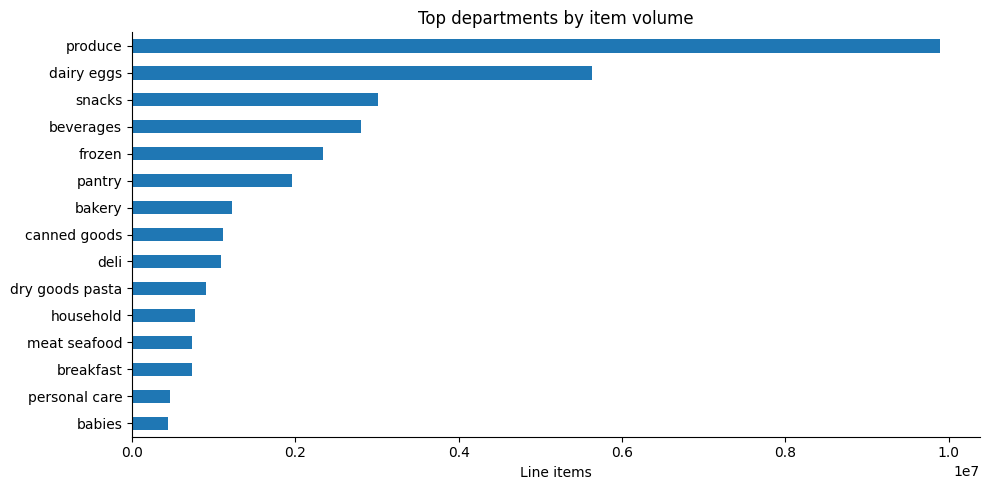

In [23]:
top_departments = department_metrics.nlargest(15, "items").sort_values("items")
ax = top_departments.plot.barh(x="department", y="items", legend=False, title="Top departments by item volume")
ax.set_xlabel("Line items")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

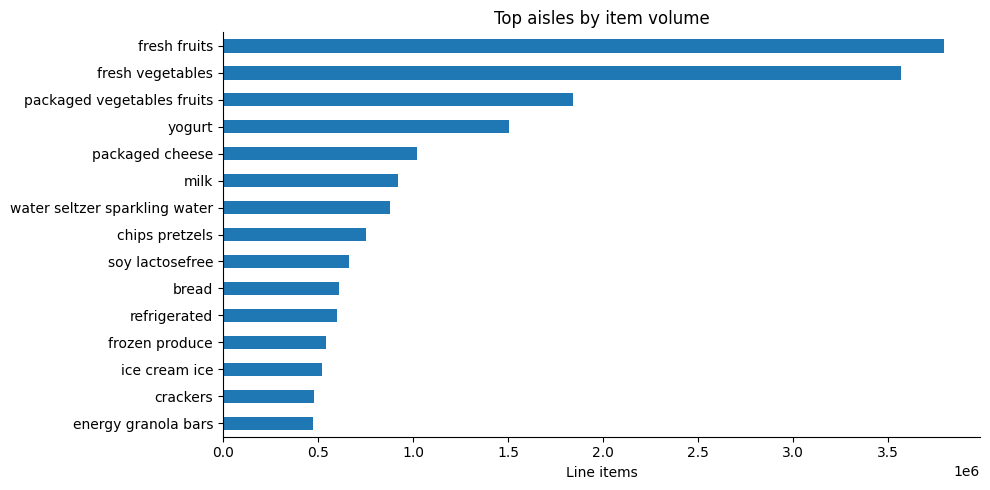

In [24]:
top_aisles = aisle_metrics.nlargest(15, "items").sort_values("items")
ax = top_aisles.plot.barh(x="aisle", y="items", legend=False, title="Top aisles by item volume")
ax.set_xlabel("Line items")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

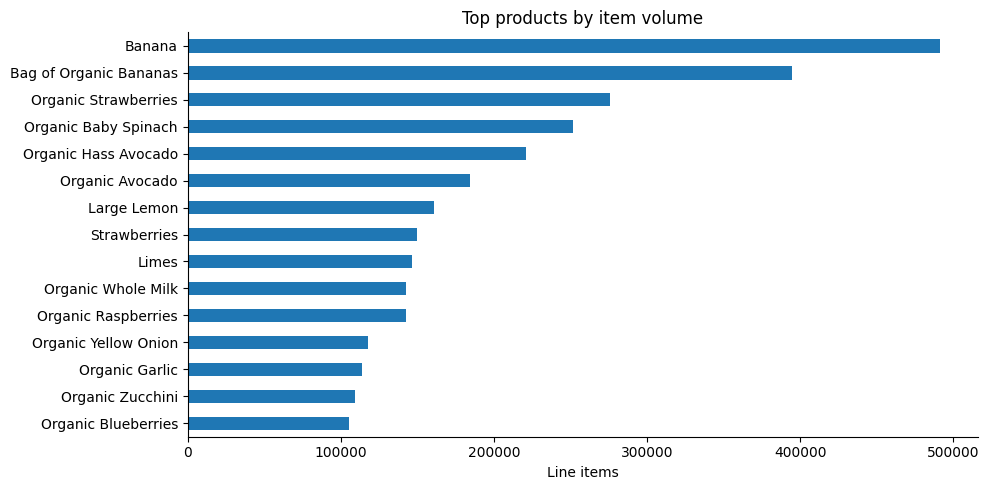

In [25]:
top_products = product_demand.nlargest(15, "items").copy()
top_products["product_name"] = top_products["product_name"].str.slice(0, 55)
top_products = top_products.sort_values("items")
ax = top_products.plot.barh(x="product_name", y="items", legend=False, title="Top products by item volume")
ax.set_xlabel("Line items")
ax.set_ylabel("")
plt.tight_layout()
plt.show()